# Evaluation of distribution of models on 60km -> 2.2km-4x over Birmingham

In [ ]:
%reload_ext autoreload

%autoreload 2

%reload_ext dotenv
%dotenv

import functools
import math
import string

import IPython
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from mlde_analysis.data import prep_eval_data
from mlde_analysis import plot_map, SUBREGIONS
from mlde_analysis.display import pretty_table, VAR_RANGES
from mlde_analysis.distribution import mean_bias, std_bias, plot_freq_density, plot_distribution_figure, compute_metrics, DIST_THRESHOLDS
from mlde_analysis.wet_dry import threshold_exceeded_prop_stats, threshold_exceeded_prop, threshold_exceeded_prop_error, threshold_exceeded_prop_change, plot_threshold_exceedence_errors, THRESHOLDS, wd_mean, wd_mean_bias
from mlde_utils import cp_model_rotated_pole
from mlde_analysis import qq_plot, reasonable_quantiles

In [ ]:
matplotlib.rcParams['figure.dpi'] = 300

In [ ]:
from mlde_analysis.default_params import *

In [ ]:
# Parameters
desc = "Comparison of diffusion models trained on just one ensemble member and one time period vs 1 ensemble member three time period vs 12 ensemble members and three time periods\nTest split\n12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set\nCompare techniques: diffusion, u-net, bilinear\n\nEvaluated on all 3 time periods and all 12 ensemble members\n"
eval_vars = ["pr"]
derived_variables_config = {}
dataset_configs = {"CPM": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr"}
split = "test"
ensemble_members = [
    "01",
    "04",
    "05",
    "06",
    "07",
    "08",
    "09",
    "10",
    "11",
    "12",
    "13",
    "15",
]
samples_per_run = 6
sample_configs = {
    "CPM": [
        {
            "label": "cCPM 1em 3TP",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_1em_cncsnpp_continuous/bham-4x_1em_pSTV",
                    "checkpoint": "epoch_120",
                    "config_hash": "8a88ee169ecf997e",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "input_xfm": "bham64_ccpm-4x_1em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "Samples": True,
            "color": "tab:orange",
            "order": 10,
        },
        {
            "label": "cCPM 12em 3TP",
            "sample_specs": [
                {
                    "fq_model_id": "score-sde/subvpsde/ukcp_local_pr_12em_cncsnpp_continuous/bham-4x_12em_pSTV",
                    "checkpoint": "epoch_20",
                    "dataset": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr",
                    "input_xfm": "bham64_ccpm-4x_12em_psl-sphum4th-temp4th-vort4th_pr-stan",
                    "variables": ["pr"],
                }
            ],
            "deterministic": False,
            "CCS": True,
            "color": "tab:blue",
            "order": 15,
        },
    ]
}
example_percentiles = {
    "CPM": {
        "DJF Wet": {"percentile": 0.8, "variable": "pr", "season": "DJF"},
        "DJF Wettest": {"percentile": 1, "variable": "pr", "season": "DJF"},
        "JJA Wet": {"percentile": 0.8, "variable": "pr", "season": "JJA"},
        "JJA Wettest": {"percentile": 1, "variable": "pr", "season": "JJA"},
    }
}
example_overrides = {}
examples_sample_idxs = [2, 5]
niterations = 30


In [ ]:
IPython.display.Markdown(desc)

Comparison of diffusion models trained on just one ensemble member and one time period vs 1 ensemble member three time period vs 12 ensemble members and three time periods
Test split
12em dataset and models, 60km inputs -> 8.8km outputs, pSTV input variable set
Compare techniques: diffusion, u-net, bilinear

Evaluated on all 3 time periods and all 12 ensemble members


In [ ]:
EVAL_DS, MODELS = prep_eval_data(sample_configs, dataset_configs, derived_variables_config, eval_vars, split, ensemble_members=ensemble_members, samples_per_run=samples_per_run)
EVAL_DS

{'CPM': <xarray.Dataset> Size: 19GB
 Dimensions:                     (model: 2, sample_id: 6, ensemble_member: 12,
                                  time: 3240, grid_latitude: 64,
                                  grid_longitude: 64, bnds: 2)
 Coordinates:
   * time                        (time) object 26kB 1981-03-01 12:00:00 ... 20...
     season                      (time) float64 26kB 1.0 1.0 1.0 ... 2.0 2.0 2.0
   * grid_latitude               (grid_latitude) float32 256B -2.49 ... 2.55
   * grid_longitude              (grid_longitude) float32 256B 357.9 ... 363.0
   * ensemble_member             (ensemble_member) <U2 96B '01' '04' ... '15'
   * model                       (model) object 16B 'cCPM 1em 3TP' 'cCPM 12em ...
     time_period                 (time) <U8 104kB 'historic' ... 'future'
     dec_adjusted_year           (time) int64 26kB 1981 1981 1981 ... 2076 2076
     stratum                     (time) <U12 156kB 'historic MAM' ... 'future ...
     tp_season_year         

In [ ]:
CPM_DAS = { var: EVAL_DS["CPM"][f"target_{var}"].rename(f"cpm_{var}") for var in eval_vars }

PRED_DAS = { 
    var: xr.concat([ 
        EVAL_DS[source][f"pred_{var}"] for source, models in MODELS.items()
    ], dim="model")  
for var in eval_vars }

VAR_DAS = {
    var: xr.merge([PRED_DAS[var], CPM_DAS[var]])
for var in eval_vars }

MODELLABEL2SPEC = { model: {"source": source} | spec for source, models in MODELS.items() for model, spec in models.items() }

## Figure: distribution

* Frequency Density Histogram of rainfall intensities
* Maps of Mean bias ($\frac{\mu_{sample}-\mu_{CPM}}{\mu_{CPM}}$) over all samples, time and ensemble members
* Std Dev Bias $\frac{\sigma_{sample}}{\sigma_{CPM}}$ over all samples, time and ensemble members

Table of:

* RMS biases
* J-S Distances
* proportion of density over thresholds

### pr

,NaN Count,RMS Mean Bias (mm/day),RMS Std Dev Bias (mm/day),Relative RMS Mean Bias (%),Relative RMS Std Dev Bias (%),J-S distance,Emu > 0.1,Emu > 0.1 - CPM > 0.1,Emu > 25,Emu > 25 - CPM > 25,Emu > 75,Emu > 75 - CPM > 75,Emu > 125,Emu > 125 - CPM > 125
model,,,,,,,,,,,,,,
cCPM 1em 3TP,0,0.09902,0.1828,3.075,3.192,0.001812,0.5272,-0.002877,0.009967,9.629e-05,0.0001009,-1.408e-05,3.88e-06,-1.2e-06
cCPM 12em 3TP,0,0.08922,0.1836,3.403,3.567,0.002809,0.5257,-0.004364,0.009527,-0.0003431,0.0001017,-1.333e-05,4.547e-06,-5.327e-07


6.2793370627572015e-09
5e-10


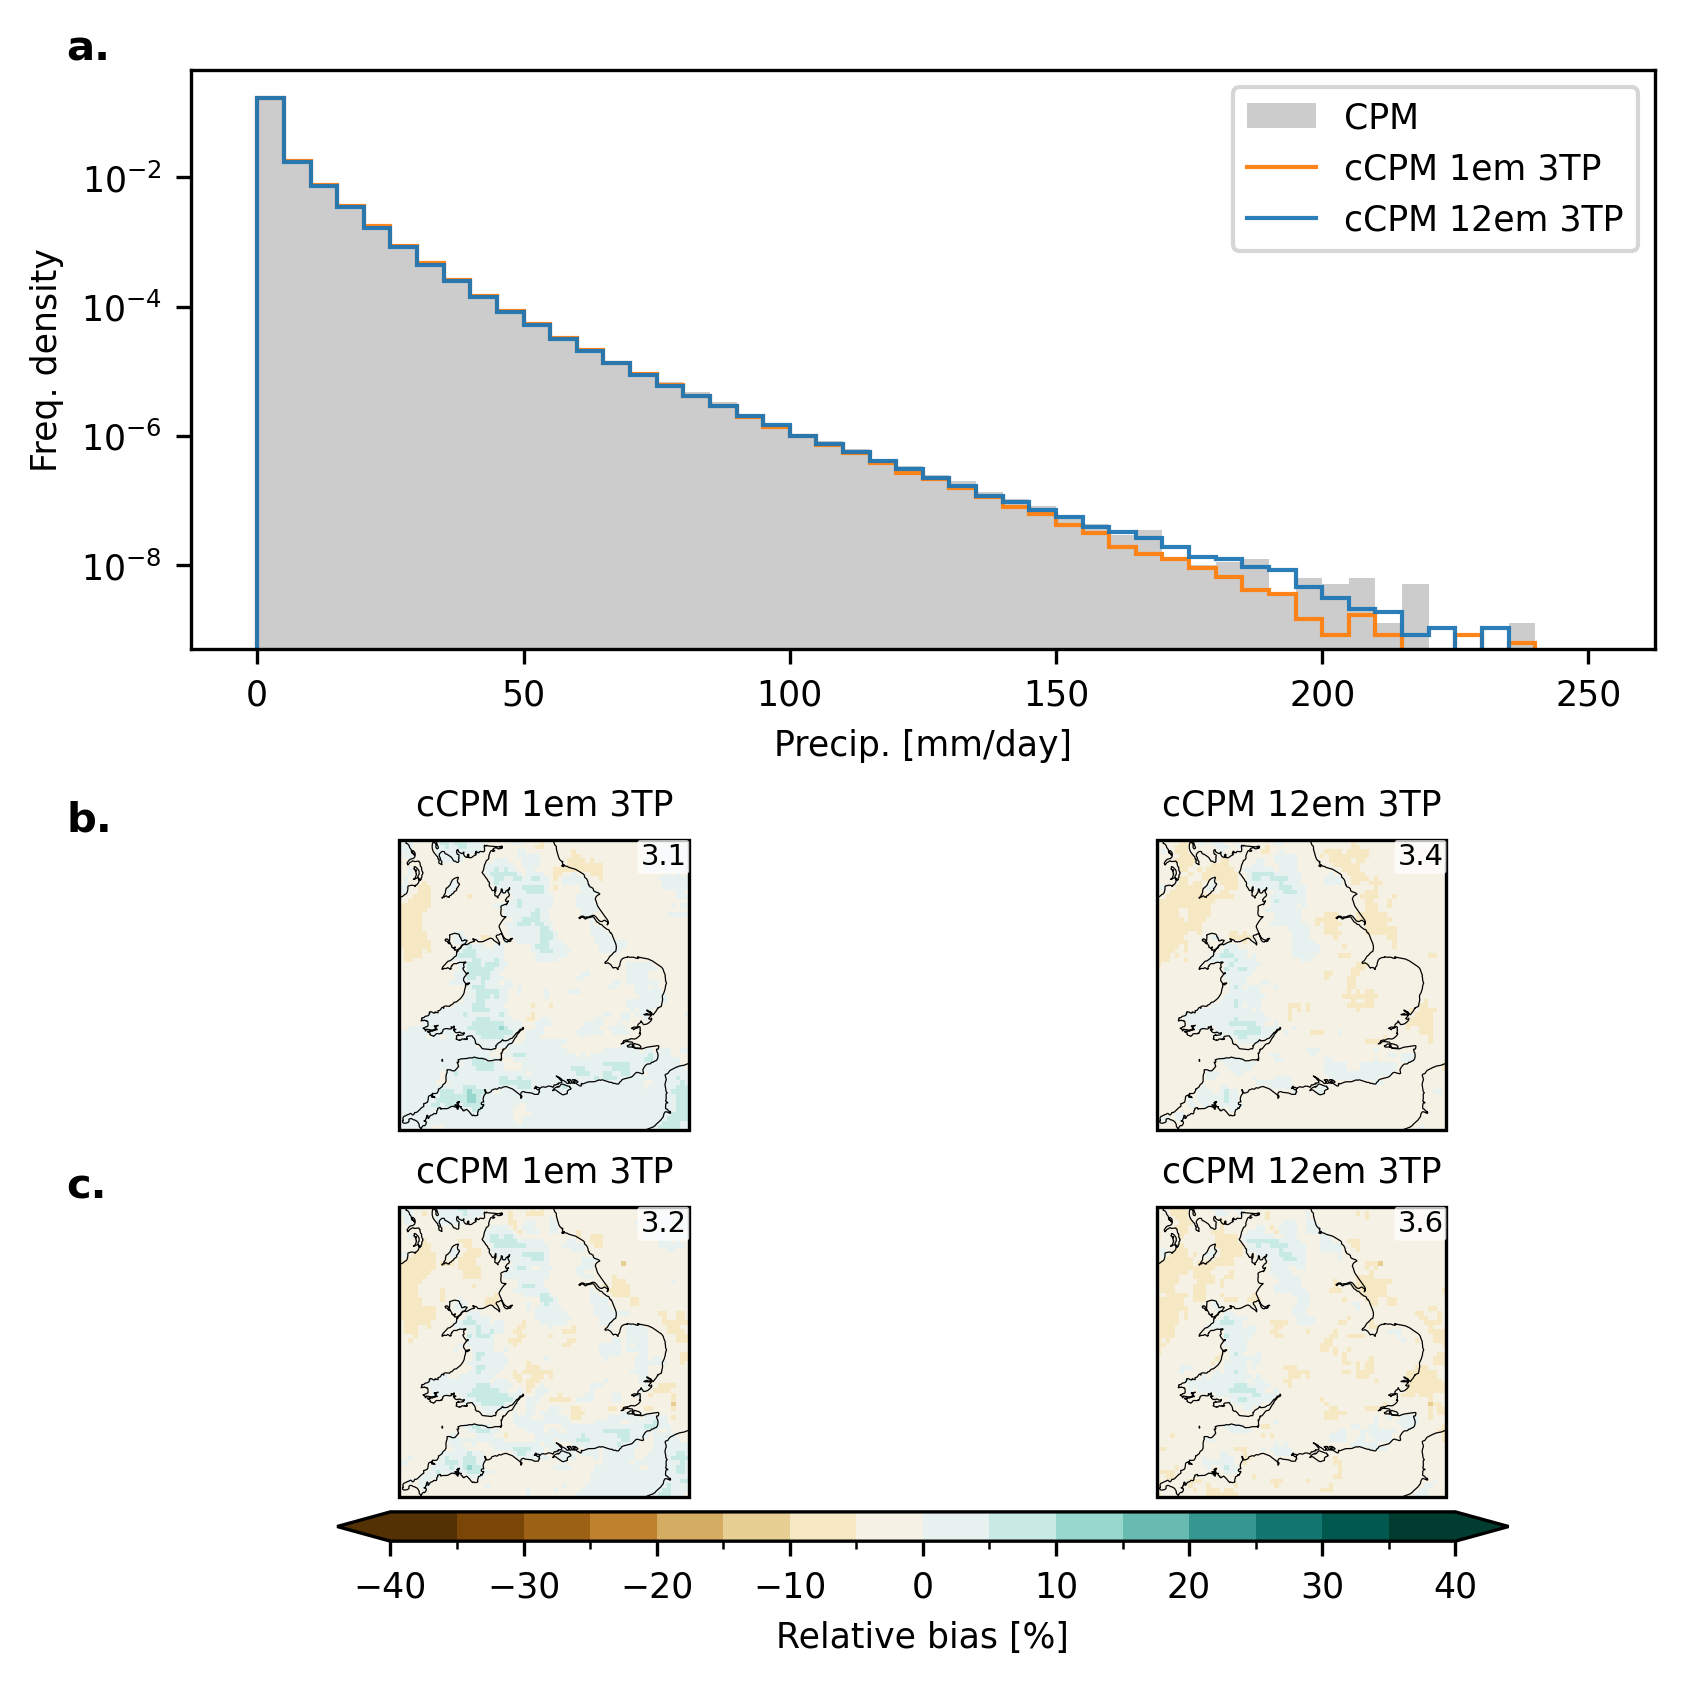

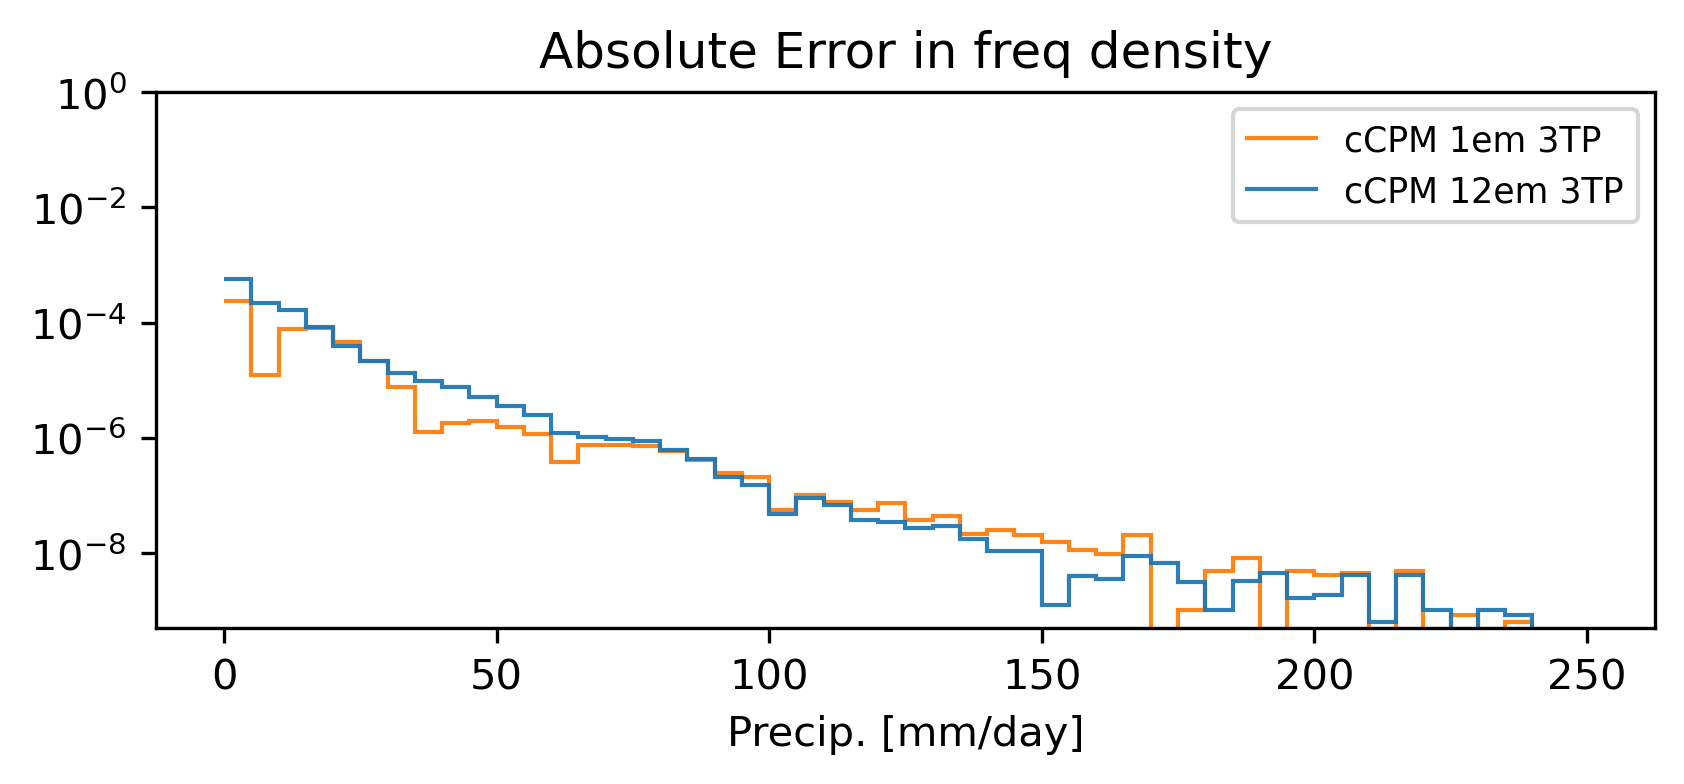

6.2793370627572015e-09
5e-10


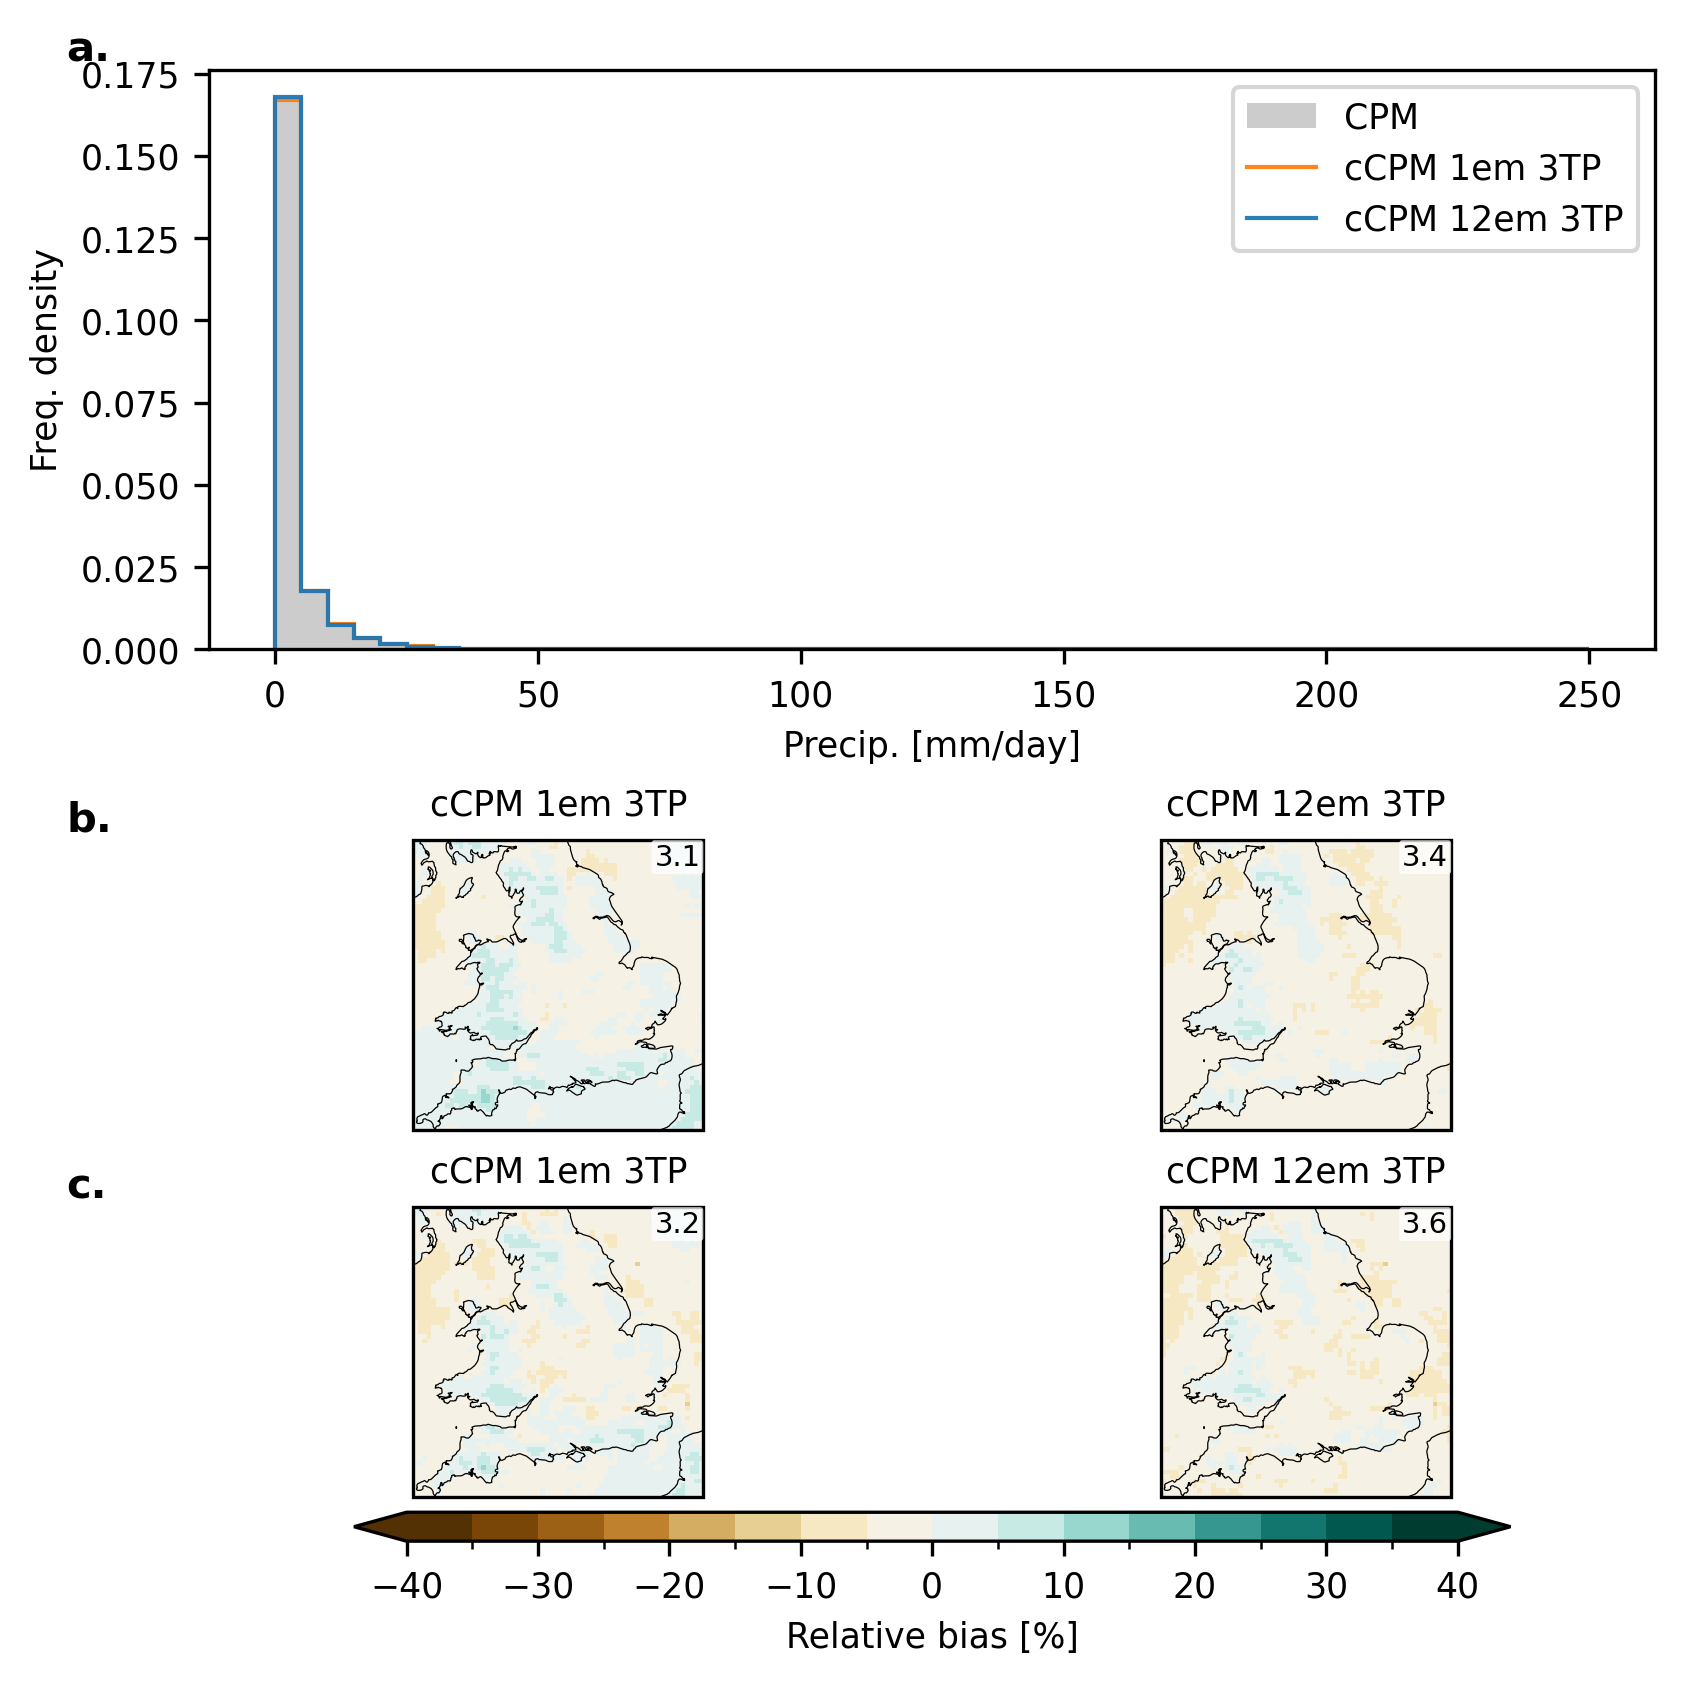

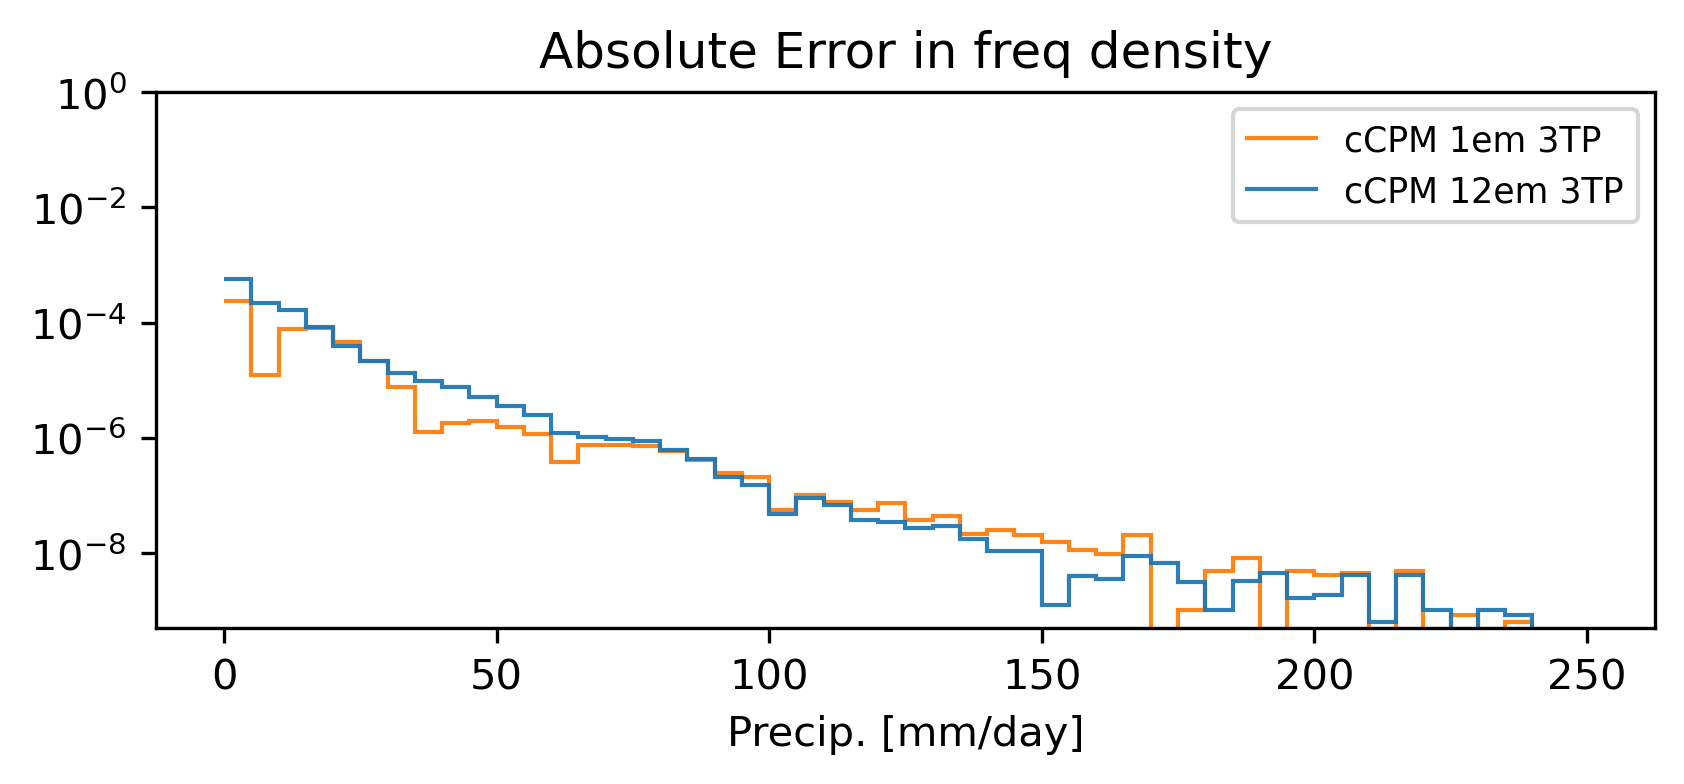

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)
    
    hist_das = PRED_DAS[var]
    cpm_da = CPM_DAS[var]
    
    metrics_ds = compute_metrics(hist_das, cpm_da, thresholds=DIST_THRESHOLDS[var])

    pretty_table(metrics_ds, round=4)
    
    normalize=(var == "pr")
    mean_biases = PRED_DAS[var].groupby("model").map(mean_bias, cpm_da=VAR_DAS[var][f"cpm_{var}"], normalize=(var=="pr"))

    std_biases = PRED_DAS[var].groupby("model").map(std_bias, cpm_da=VAR_DAS[var][f"cpm_{var}"], normalize=(var=="pr"))

    bias_kwargs = {"style": f"{var}Bias"}
    for fd_kwargs in [{"yscale": "log"}, {"yscale": "linear"}]:
        fig = plt.figure(layout="constrained", figsize=(5.5, 5.5))
        error_fig = plt.figure(layout="constrained", figsize=(5.5, 2.5))
        error_axd = error_fig.subplot_mosaic([["Error"]])
        error_ax = error_axd["Error"]
        axd = plot_distribution_figure(
            fig,
            hist_das,
            cpm_da,
            mean_biases,
            std_biases,
            MODELLABEL2SPEC,
            error_ax=error_ax, hrange=VAR_RANGES[var], fd_kwargs=fd_kwargs, bias_kwargs=bias_kwargs
        )
        if var == "relhum150cm":
            axd["Density"].axvline(x=100, color='k', linestyle='--', linewidth=1)
        
        plt.show()

## QQ plots

### pr

-8


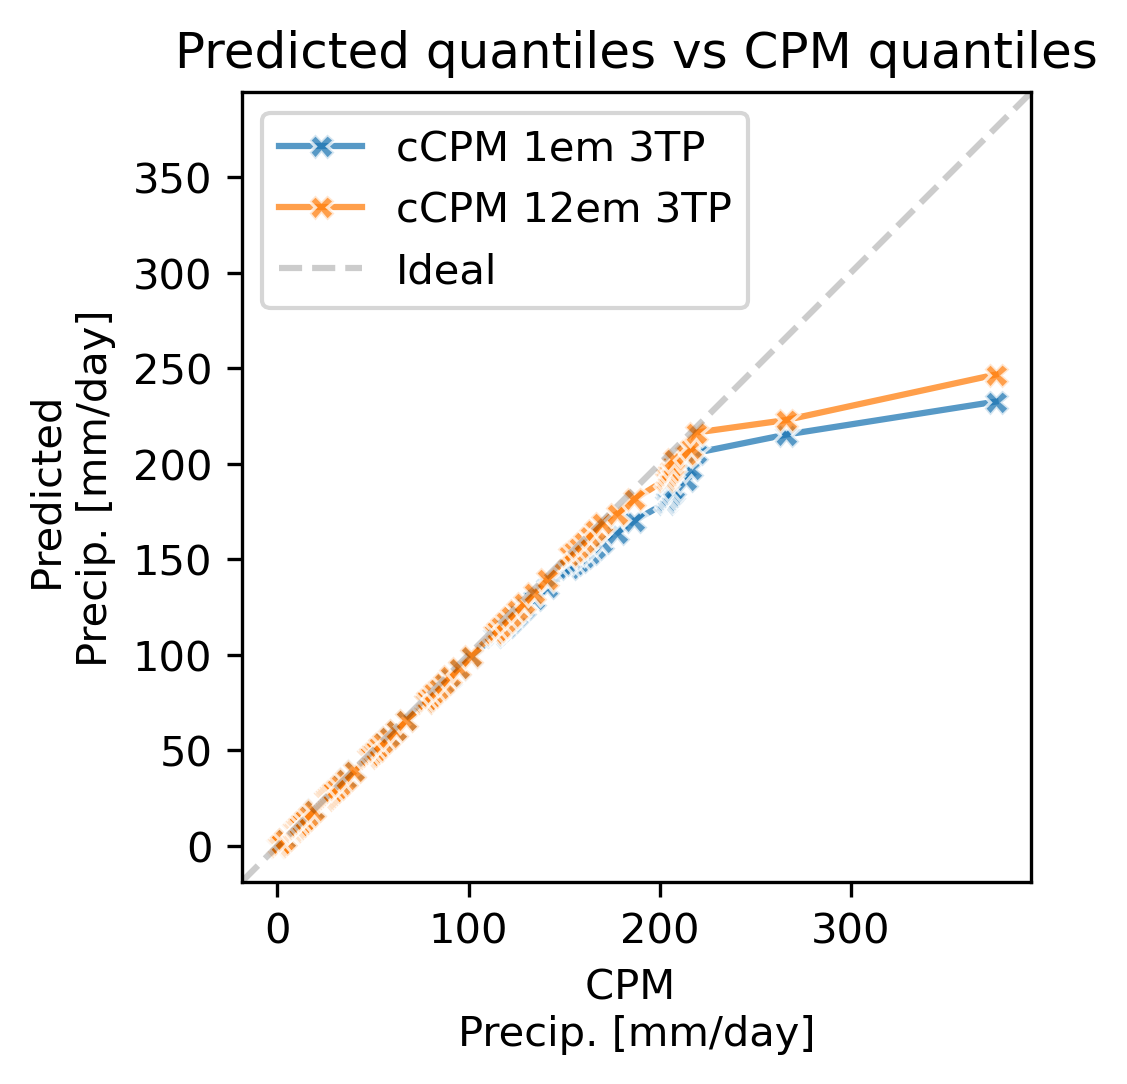

In [ ]:
quantile_dims=["ensemble_member", "time", "grid_latitude", "grid_longitude"]

for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)

    quantiles = reasonable_quantiles(CPM_DAS[var])
    cpm_quantiles = CPM_DAS[var].quantile(quantiles, dim=quantile_dims).rename("target_q")

    for source, ds in EVAL_DS.items():
        pred_da = ds[f"pred_{var}"]
        pred_quantiles = pred_da.quantile(quantiles, dim=quantile_dims).rename("pred_q")

        layout="constrained"

        fig, ax = plt.subplots(figsize=(3.5, 3.5), layout="constrained")

        xlabel = f"CPM \n{xr.plot.utils.label_from_attrs(da=CPM_DAS[var])}"
        ylabel = f"Predicted \n{xr.plot.utils.label_from_attrs(da=pred_da)}"

        qq_plot(ax, cpm_quantiles, pred_quantiles, title=f"Predicted quantiles vs CPM quantiles", xlabel=xlabel, ylabel=ylabel)

    plt.show()

## Figure: subdomain

### pr

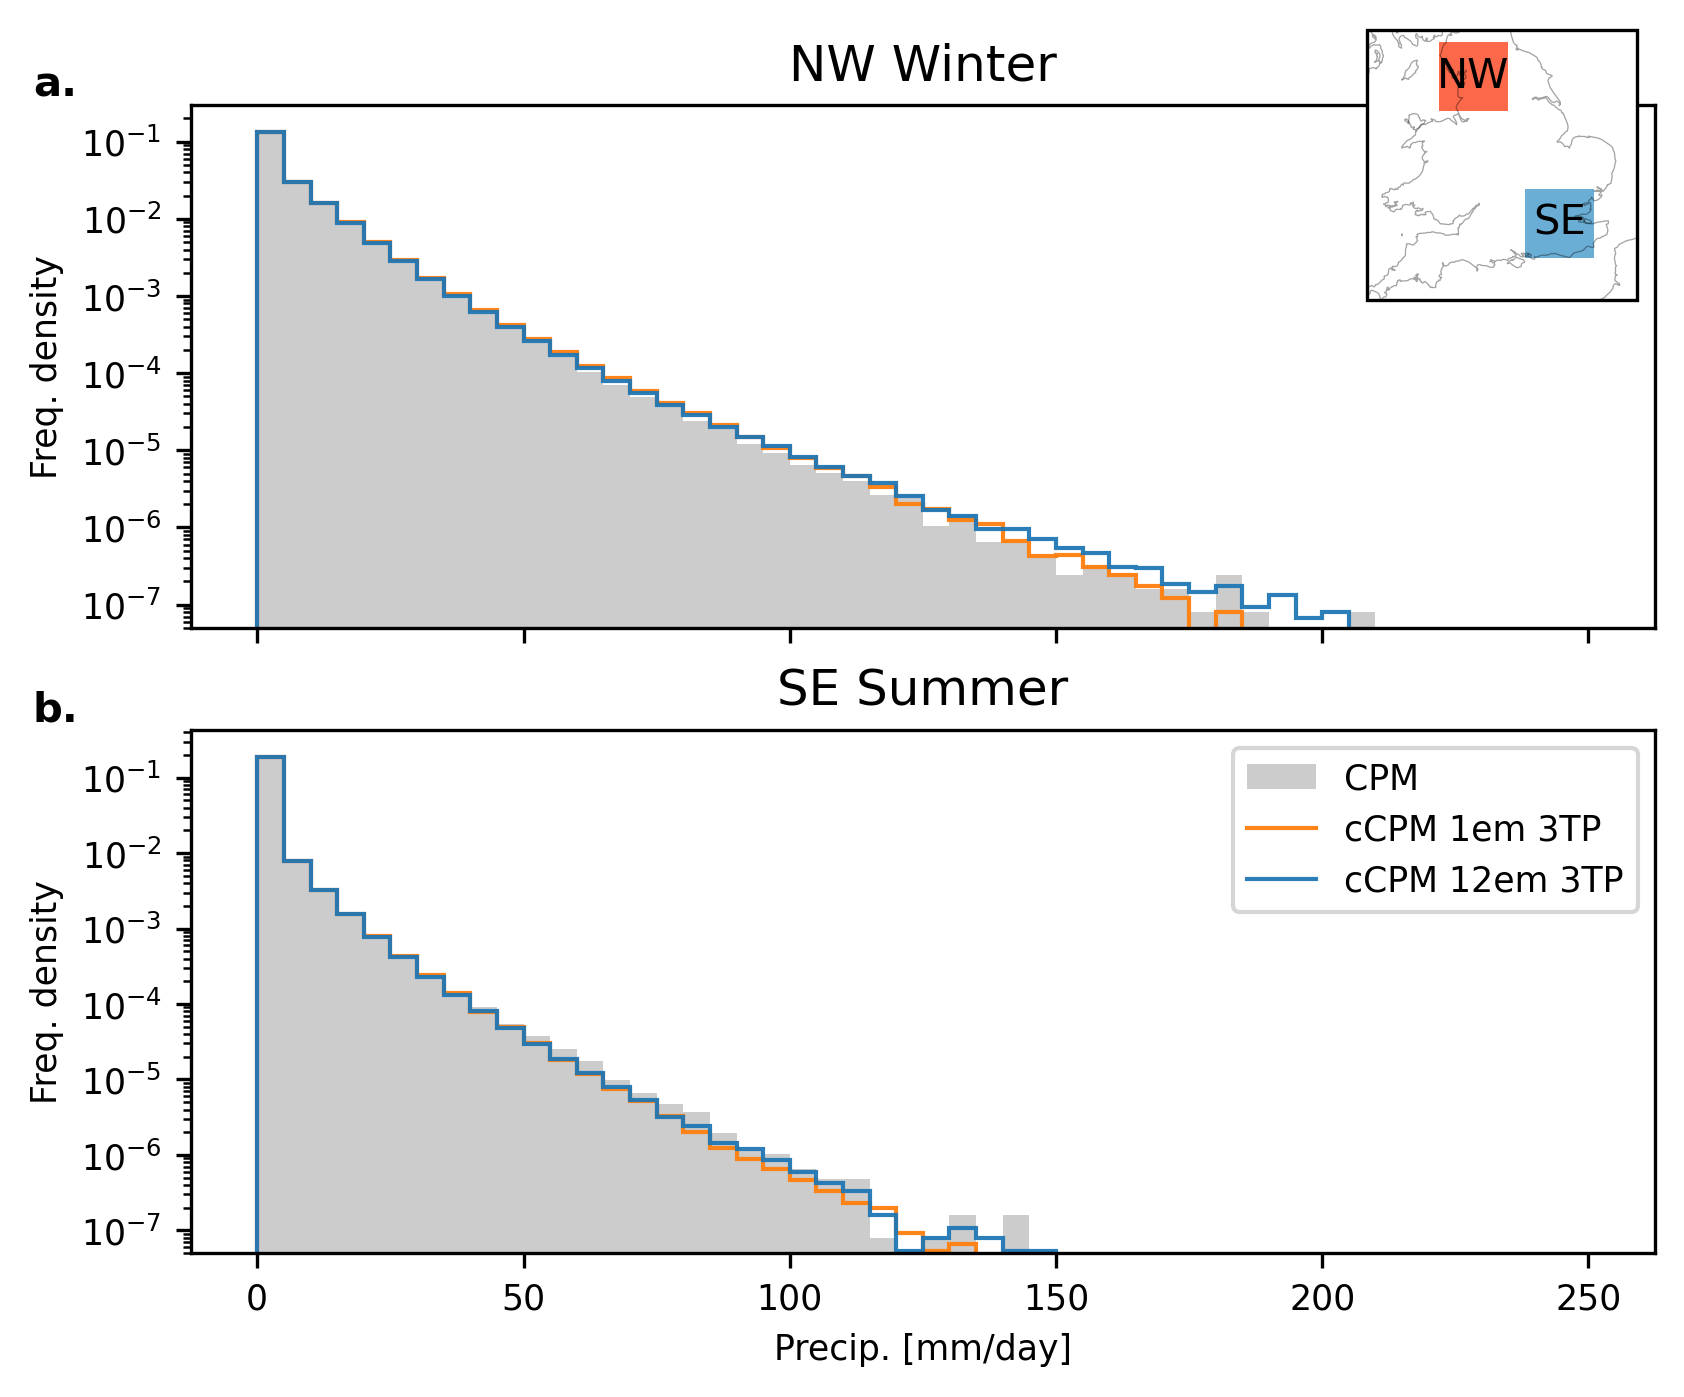

In [ ]:
for var in eval_vars:
    IPython.display.display_markdown(f"### {var}", raw=True)

    fd_fig = plt.figure(figsize=(5.5, 4.5), layout="constrained")

    human_names = {
        "DJF": "Winter",
        "JJA": "Summer",
    }

    axd = fd_fig.subplot_mosaic([["NW"], ["SE"]], sharex=True)
    
    for i, (srname, season) in enumerate([("NW", "DJF"), ("SE", "JJA")]):

        season_mask = CPM_DAS[var]["time"]["time.season"] == season

        srseason_cpm_da = CPM_DAS[var].isel(**SUBREGIONS[srname]).sel(time=season_mask)

        srseason_hist_data = [
            dict(data=EVAL_DS[source][f"pred_{var}"].sel(model=model).isel(**SUBREGIONS[srname]).sel(time=season_mask), label=model, color=spec["color"]) for source, mconfigs in MODELS.items() for model, spec in mconfigs.items()
        ]

        ax = axd[srname]
        if var == "pr":
            kwargs = {
                "yscale": "log",
            }
        else:
            kwargs = {
                "yscale": "linear",
            }
        plot_freq_density(srseason_hist_data, ax=ax, target_da=srseason_cpm_da, linewidth=1, hrange=VAR_RANGES[var], **kwargs)
        ax.set_title(f"{srname} {human_names[season]}")

        if i == 0:
            ax.set_xlabel("")
            ax.get_legend().remove()
            reg_ax = fd_fig.add_axes([0.8, 0.8, 0.2, 0.2], projection=cp_model_rotated_pole)
            # reg_ax = fd_fig.subplots(1, subplot_kw = dict(projection=cp_model_rotated_pole))
            nw_cpm_da = CPM_DAS[var].isel(**SUBREGIONS["NW"])
            se_cpm_da = CPM_DAS[var].isel(**SUBREGIONS["SE"])
            plot_map(10*xr.ones_like(nw_cpm_da.isel(ensemble_member=0, time=0)), ax=reg_ax, style=None, cmap="Reds", cl_kwargs=dict(alpha=0.2))
            plot_map(1*xr.ones_like(se_cpm_da.isel(ensemble_member=0, time=0)), ax=reg_ax, style=None, cmap="Blues", cl_kwargs=dict(alpha=0.2))
            reg_ax.annotate("NW", xy=(nw_cpm_da.grid_longitude.mean().values.item(), nw_cpm_da.grid_latitude.mean().values.item()), xycoords="data", fontsize="medium", ha="center", va="center")
            reg_ax.annotate("SE", xy=(se_cpm_da.grid_longitude.mean().values.item(), se_cpm_da.grid_latitude.mean().values.item()), xycoords="data", fontsize="medium", ha="center", va="center")
            reg_ax.set_extent([-2, 3, -2.5, 2.5], crs=cp_model_rotated_pole)


        ax.annotate(f"{string.ascii_lowercase[i]}.", xy=(0.02, 1.0), xycoords=("figure fraction", "axes fraction"), weight='bold', ha="left", va="bottom")

    plt.show()

## Figure: Threshold exceedence

Threshold: 0.1mm/day 
 
 
   
   
 % Threshold exceeded 
 
 
 season 
 model 
   
 
 
 
 
 Annual 
 cCPM 1em 3TP 
 52.7 
 
 
 cCPM 12em 3TP 
 52.6 
 
 
 CPM 
 53.0 
 
 
 DJF 
 cCPM 1em 3TP 
 66.6 
 
 
 cCPM 12em 3TP 
 66.4 
 
 
 CPM 
 67.4 
 
 
 MAM 
 cCPM 1em 3TP 
 56.6 
 
 
 cCPM 12em 3TP 
 56.2 
 
 
 CPM 
 55.7 
 
 
 JJA 
 cCPM 1em 3TP 
 37.1 
 
 
 cCPM 12em 3TP 
 36.9 
 
 
 CPM 
 36.9 
 
 
 SON 
 cCPM 1em 3TP 
 50.5 
 
 
 cCPM 12em 3TP 
 50.8 
 
 
 CPM 
 52.0

#### Threshold: 0.1mm/day

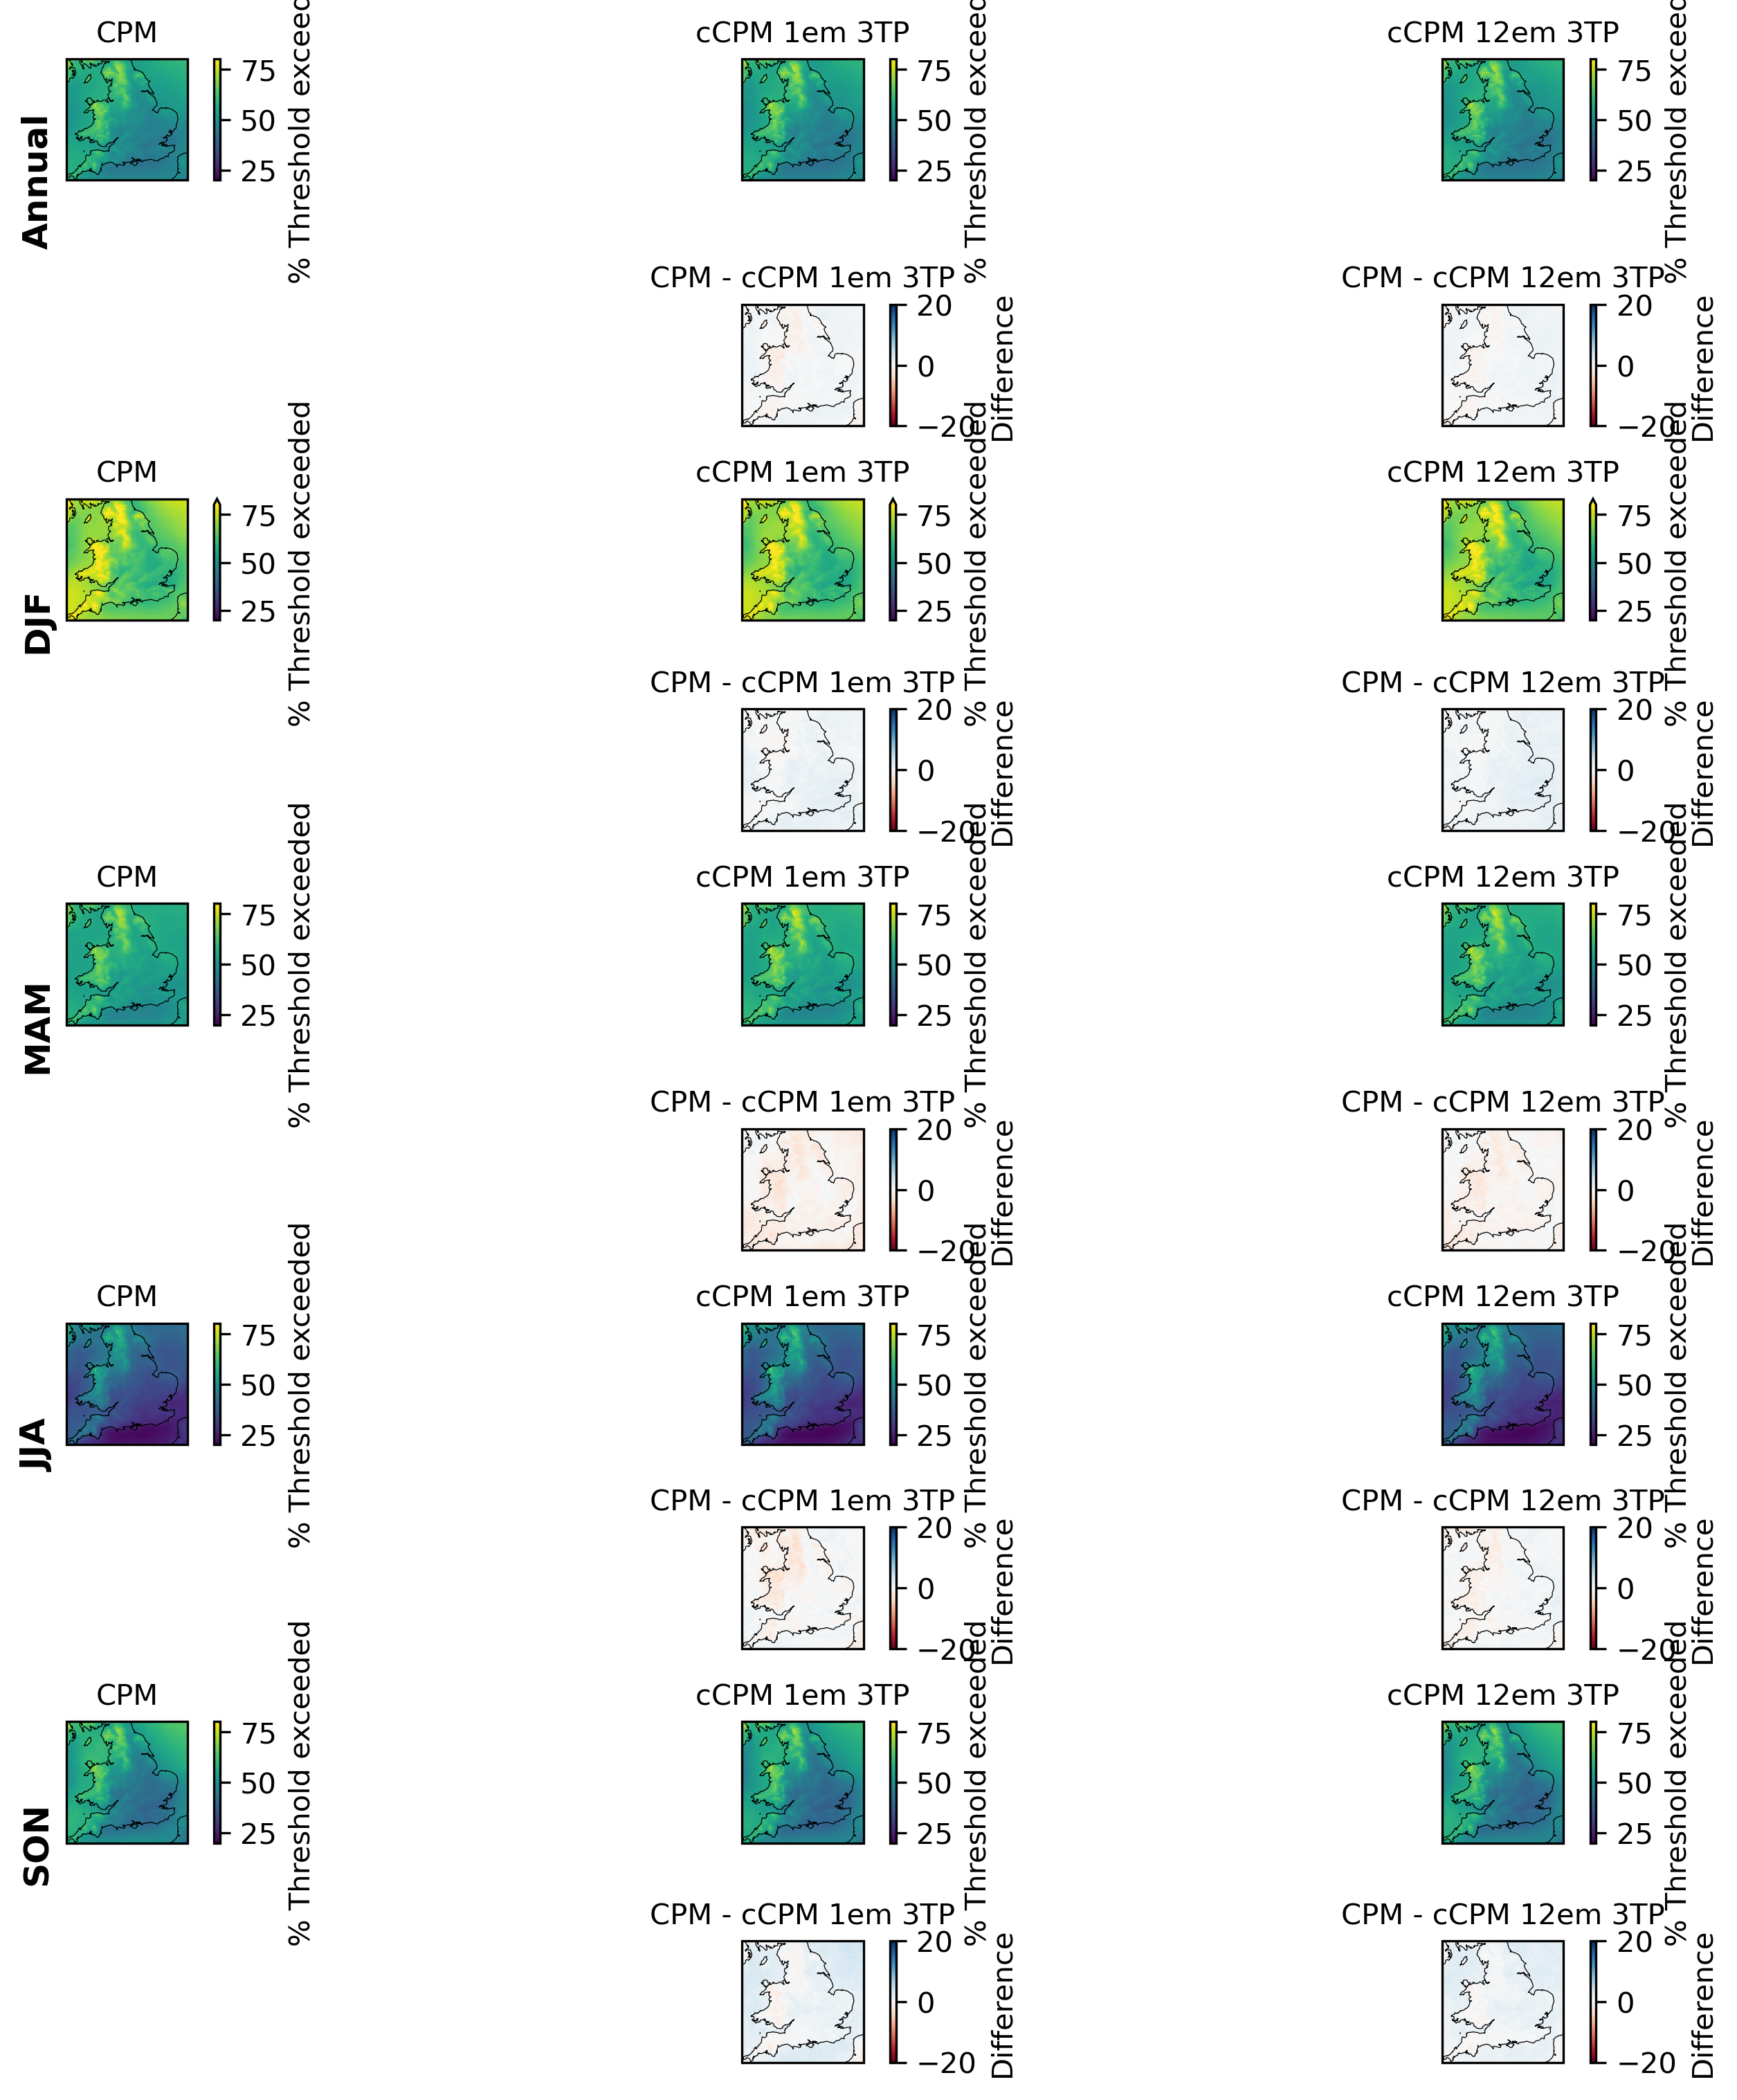

In [ ]:
for var, thresholds in THRESHOLDS.items():
    if var in eval_vars:
        model_das = [
            EVAL_DS[source][f"pred_{var}"].sel(model=model)
            for source, mconfigs in MODELS.items() for model, spec in mconfigs.items()
        ]

        threshold_exceeded_stats = { threshold: threshold_exceeded_prop_stats(VAR_DAS[var][f"pred_{var}"], CPM_DAS[var], threshold) for threshold in thresholds }

        dfs = [threshold_exceeded_stats[threshold].mean(dim=["grid_latitude", "grid_longitude"]).to_dataframe().style.set_table_attributes("style='display:inline'").set_caption(f"Threshold: {threshold}{CPM_DAS[var].attrs['units']}").format(precision=1).to_html() for threshold in thresholds]

        IPython.display.display_html(functools.reduce(lambda v, e: v+e, dfs), raw=True)

        for threshold in thresholds:
            IPython.display.display_markdown(f"#### Threshold: {threshold}{CPM_DAS[var].attrs['units']}", raw=True)

            plot_threshold_exceedence_errors(threshold_exceeded_stats[threshold])

            plt.show()

## Rough: wet-day mean

#### Threshold: 0.1mm/day

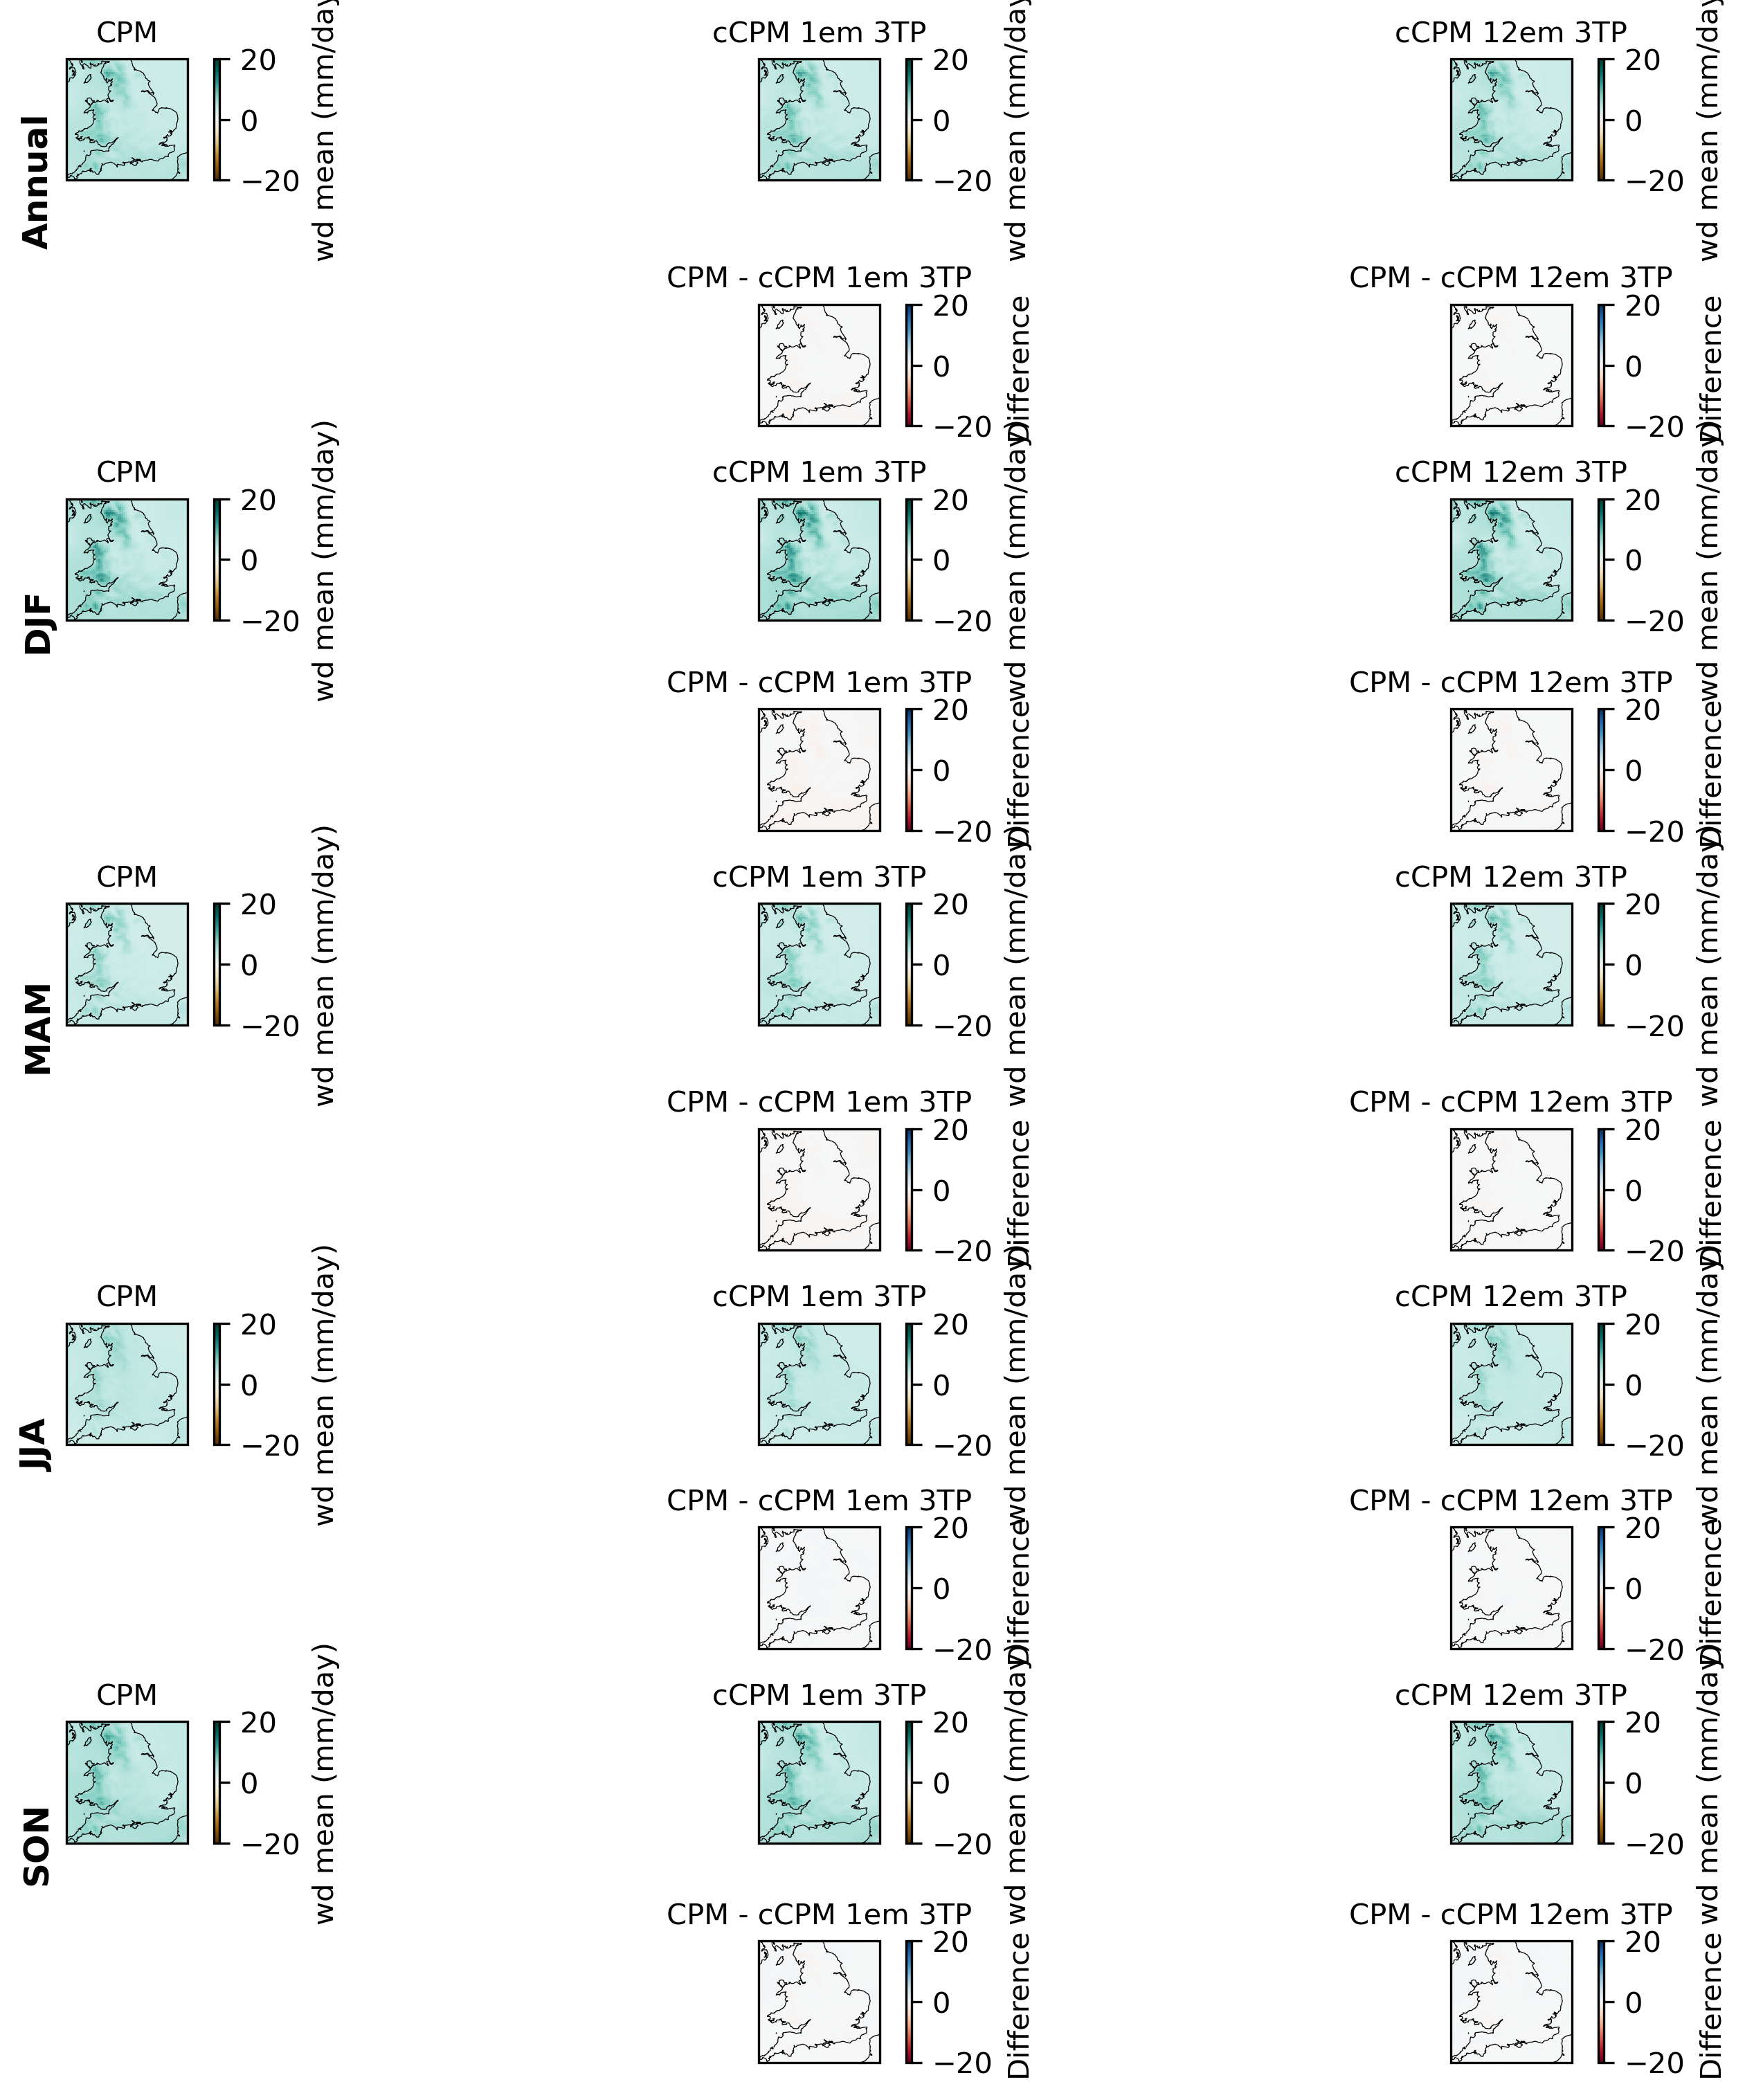

In [ ]:
model_das = [
    EVAL_DS[source]["pred_pr"].sel(model=model)
    for source, mconfigs in MODELS.items() for model, spec in mconfigs.items()
]

change_stats = { var: { threshold: threshold_exceeded_prop_stats(VAR_DAS[var][f"pred_{var}"], CPM_DAS[var], threshold=threshold, threshold_exceeded_prop_statistic=wd_mean) for threshold in thresholds } for var, thresholds in THRESHOLDS.items() if var in eval_vars }

for var, thresholds in THRESHOLDS.items():
    if var in eval_vars:
        for threshold in thresholds:
            IPython.display.display_markdown(f"#### Threshold: {threshold}mm/day", raw=True)
            
            plot_threshold_exceedence_errors(change_stats[var][threshold], style="change")
        
            plt.show()